# What Content and Timing Factors Drive Social Media Engagement?

This project investigates what content and timing factors drive social media engagement, using three datasets: Instagram Analytics, Viral Social Media Trends, and YouTube Data API v3.

In [9]:
import os
from config import DATA_DIR, INSTAGRAM_CSV, VIRAL_TRENDS_CSV, YOUTUBE_CSV, INSTAGRAM_URL, VIRAL_TRENDS_URL
from load import (load_local_csv, get_youtube_data, save_data, download_from_drive)
from process import process_instagram, process_viral_trends
from analyze import run_full_analysis

os.makedirs(DATA_DIR, exist_ok=True)

# Instagram Analytics

Loaded Instagram_Analytics.csv, rows: 29999
Processing Instagram dataset
Instagram: 29999 rows after cleaning.
Analysing: Instagram
Correlations with 'engagement_rate':likes                 0.506096
saves                 0.478121
shares                0.468681
comments              0.451598
account_id            0.009414
reach                 0.006187
followers_gained      0.000509
caption_length        0.000497
hashtags_count       -0.001246
follower_count       -0.005620
has_call_to_action   -0.007044
post_hour            -0.007065
impressions          -0.020682
Name: engagement_rate, dtype: float64
Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/Instagram_correlation.png


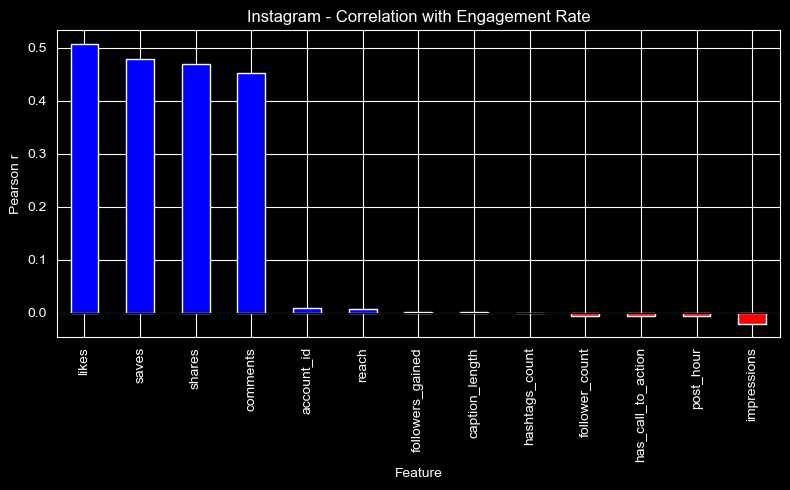

Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/Instagram_by_hour.png


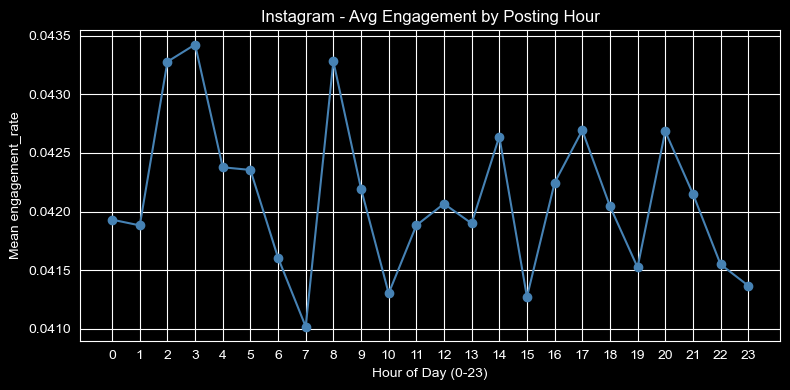

  Skipping platform plot for Instagram (missing columns).


In [10]:
download_from_drive(INSTAGRAM_URL, INSTAGRAM_CSV)

ig_raw = load_local_csv(INSTAGRAM_CSV)
ig = process_instagram(ig_raw)
run_full_analysis(ig, "Instagram", notebook_plot=True)

# Viral Social Media Trends

Loaded Cleaned_Viral_Social_Media_Trends.csv, rows: 5000
Processing Viral Trends dataset
  Viral Trends: 4637 rows after cleaning.
Analysing: ViralTrends
Correlations with 'engagement_rate':likes       0.360376
shares      0.074817
comments    0.032752
views      -0.694402
Name: engagement_rate, dtype: float64
Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/ViralTrends_correlation.png


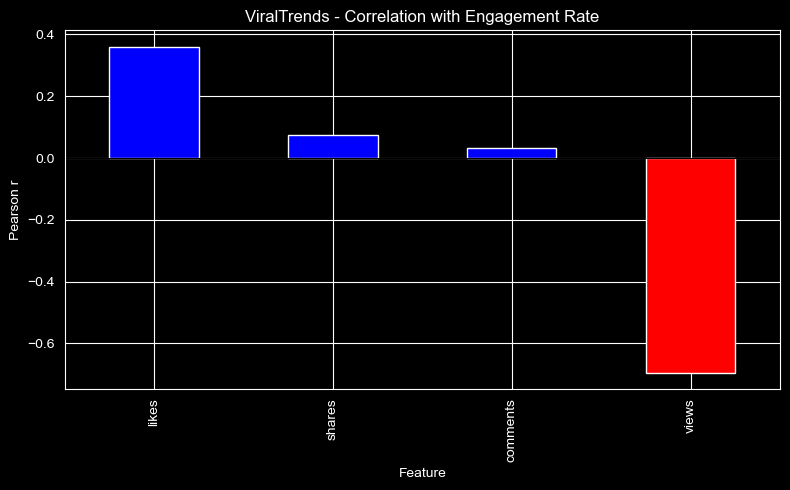

Skipping hour plot for ViralTrends (missing columns).
Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/ViralTrends_by_platform.png


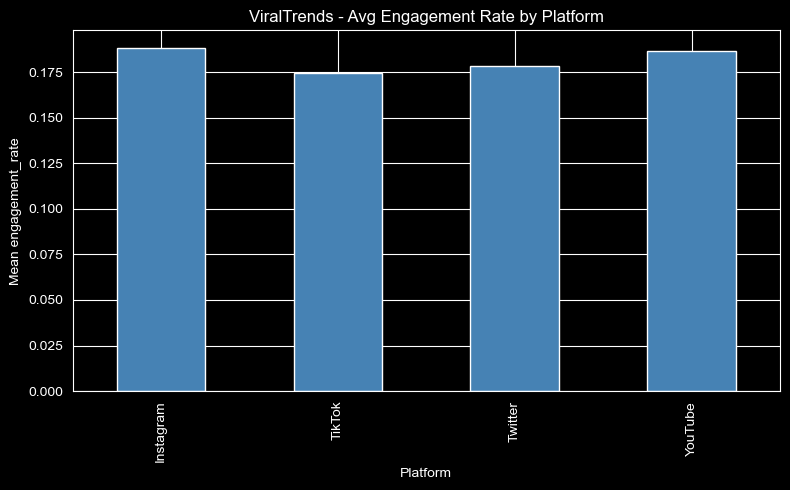

In [11]:
download_from_drive(VIRAL_TRENDS_URL, VIRAL_TRENDS_CSV)
vt_raw = load_local_csv(VIRAL_TRENDS_CSV)
vt = process_viral_trends(vt_raw)
run_full_analysis(vt, "ViralTrends", notebook_plot=True)

## YouTube Data API v3

Getting YouTube data
Collected 400 videos
Saved -> youtube_collected.csv
Analysing: YouTube
Correlations with 'engagement_rate':post_hour        0.140090
tags_count       0.115401
comment_count    0.115006
engagement      -0.024020
like_count      -0.024948
title_length    -0.157656
view_count      -0.165256
Name: engagement_rate, dtype: float64
Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/YouTube_correlation.png


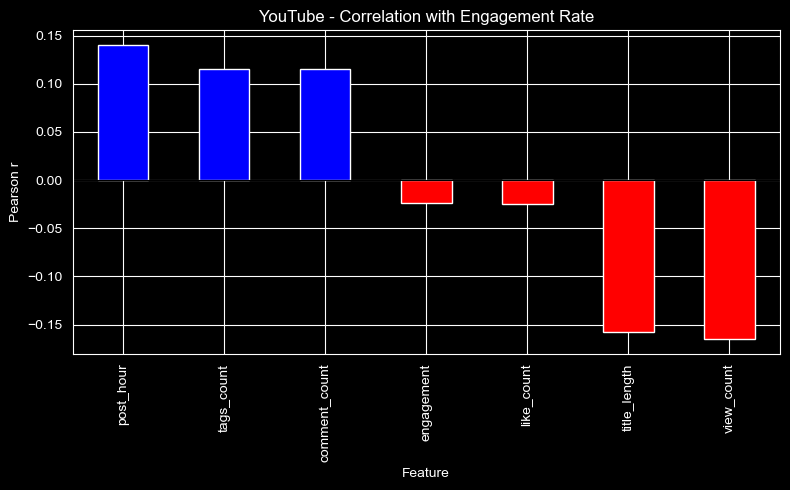

Saved -> /Users/kaci/Desktop/finalproject_Kexuan_Liang/src/../results/YouTube_by_hour.png


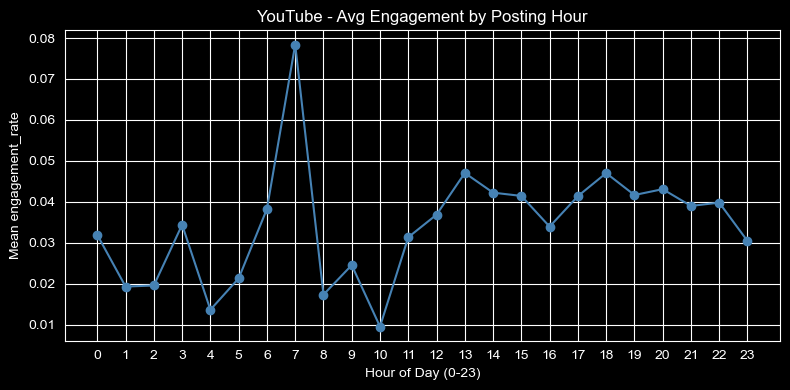

  Skipping platform plot for YouTube (missing columns).


In [12]:
yt = get_youtube_data()
if yt is not None:
    save_data(yt, YOUTUBE_CSV)
    run_full_analysis(yt, "YouTube", notebook_plot=True)